<h1 style="background-color:#FF9800;font-family:Georgia;font-size:200%;color:black;text-align:center;border-radius:20px 20px;"><b>Smartphone Features vs Market Pricing: Data Cleaning and EDA</b></h1>

# **INTRODUCTION**

This project analyzes a smartphone dataset containing brand, model, RAM, storage, color, contract status, and price. The goal is to preprocess the data, clean it, and perform exploratory data analysis (EDA) to identify patterns and trends in smartphone pricing.

# **Problem Statement and Real-World Relevance**

The aim is to analyze smartphone data to understand how features such as RAM, storage, and brand influence prices.

In the real world, companies and marketplaces use this type of analysis to understand market trends, customer preferences, and pricing strategies. As a customer, it helps make an informed decision when buying a smartphone.

<h1 style="color:#F57C00;">1. Importing Libraries</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
print("Libraries imported successfully.")

Libraries imported successfully.


<h1 style="color:#F57C00;">2. Loading The Dataset</h1>

In [2]:
df = pd.read_csv("smartphones (1).csv")
df_original = df.copy()  # preserve raw data for visualization
print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (1816, 8)


,Smartphone,Brand,Model,RAM,Storage,Color,Free,Final Price
0,Realme C55 8/256GB Sunshower Libre,Realme,C55,8.0,256.0,Yellow,Yes,231.60
1,Samsung Galaxy M23 5G 4/128GB Azul Libre,Samsung,Galaxy M23,4.0,128.0,Blue,Yes,279.00
2,Motorola Moto G13 4/128GB Azul Lavanda Libre,Motorola,Moto G13,4.0,128.0,Blue,Yes,179.01
3,Xiaomi Redmi Note 11S 6/128GB Gris Libre,Xiaomi,Redmi Note 11S,6.0,128.0,Gray,Yes,279.99
4,Nothing Phone (2) 12/512GB Blanco Libre,Nothing,Phone (2),12.0,512.0,White,Yes,799.00


<h1 style="color:#F57C00;">3. Understanding The Dataset</h1>

In [3]:
df.shape

(1816, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1816 non-null   object 
 1   Brand        1816 non-null   object 
 2   Model        1816 non-null   object 
 3   RAM          1333 non-null   float64
 4   Storage      1791 non-null   float64
 5   Color        1816 non-null   object 
 6   Free         1816 non-null   object 
 7   Final Price  1816 non-null   float64
dtypes: float64(3), object(5)
memory usage: 113.6+ KB


In [5]:
df.describe()

,RAM,Storage,Final Price
count,1333.00000,1791.000000,1816.000000
mean,5.96099,162.652150,492.175573
std,2.66807,139.411605,398.606183
min,1.00000,2.000000,60.460000
25%,4.00000,64.000000,200.990000
50%,6.00000,128.000000,349.990000
75%,8.00000,256.000000,652.717500
max,12.00000,1000.000000,2271.280000


In [6]:
df.describe(include="object")

,Smartphone,Brand,Model,Color,Free
count,1816,1816,1816,1816,1816
unique,1816,37,383,17,2
top,Xiaomi Redmi Note 9S 6/128GB Dual SIM Gris Libre,Samsung,iPhone 13,Black,Yes
freq,1,458,60,537,1772


# **Dataset Description**

### Dataset Size
- **Total rows (records):** 1816 smartphones
- **Total columns (attributes):** 8 features

### Attributes

| Attribute | Description |
|-----------|-------------|
| Smartphone | Full name of the smartphone |
| Brand | Manufacturer of the phone |
| Model | Specific model |
| RAM | RAM capacity (GB) |
| Storage | Internal storage (GB) |
| Color | Color variant |
| Free | Contract-free status (Yes/No) |
| Final Price | Selling price (€) |

### Target Variable
**Final Price** — understanding how other features influence price.

<h1 style="color:#F57C00;">4. Handling Missing Values</h1>

In [7]:
# Check missing values before doing anything
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Smartphone       0
Brand            0
Model            0
RAM            483
Storage         25
Color            0
Free             0
Final Price      0
dtype: int64

Total missing values: 508


### FIX: Proper median imputation BEFORE snapping to valid categories

**Bug in original notebook:** The lambda function that snapped RAM/Storage to the nearest valid value was applied *directly on the raw column* which still contained `NaN` values. When NumPy computes `abs(valid_values - NaN)`, every difference becomes `NaN`, and `argmin()` on an all-NaN array silently returns index 0. This means **all 483 missing RAM entries were incorrectly assigned 4 GB** (the first valid value), regardless of the actual data distribution.

**Fix:** Impute missing values with the **median** of non-null entries first, then snap to the nearest valid category.

In [8]:
# Step 4.1 — Impute missing RAM and Storage with their medians FIRST
ram_median = df["RAM"].median()
storage_median = df["Storage"].median()
print(f"RAM median (for imputation): {ram_median} GB")
print(f"Storage median (for imputation): {storage_median} GB")

df["RAM"].fillna(ram_median, inplace=True)
df["Storage"].fillna(storage_median, inplace=True)

print("\nMissing values after imputation:")
print(df[["RAM", "Storage"]].isnull().sum())

RAM median (for imputation): 6.0 GB
Storage median (for imputation): 128.0 GB

Missing values after imputation:
RAM        0
Storage    0
dtype: int64


/tmp/ipykernel_4968/2704908722.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["RAM"].fillna(ram_median, inplace=True)
/tmp/ipykernel_4968/2704908722.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [9]:
# Step 4.2 — Snap to nearest realistic category values
valid_ram_values = np.array([2, 3, 4, 6, 8, 12])
valid_storage_values = np.array([16, 32, 64, 128, 256, 512])

df["RAM"] = df["RAM"].apply(
    lambda x: int(valid_ram_values[np.abs(valid_ram_values - x).argmin()])
)
df["Storage"] = df["Storage"].apply(
    lambda x: int(valid_storage_values[np.abs(valid_storage_values - x).argmin()])
)

print("RAM values after snapping:", sorted(df["RAM"].unique()))
print("Storage values after snapping:", sorted(df["Storage"].unique()))

RAM values after snapping: [np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(8), np.int64(12)]
Storage values after snapping: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512)]


In [10]:
# Verify no missing values remain
print(df.isnull().sum())

Smartphone     0
Brand          0
Model          0
RAM            0
Storage        0
Color          0
Free           0
Final Price    0
dtype: int64


<h1 style="color:#F57C00;">5. Handling Duplicates</h1>

In [11]:
print("Duplicate rows:", df.duplicated().sum())
dupes = df[df.duplicated(keep=False)]
if len(dupes) > 0:
    print("Duplicate entries:")
    display(dupes)
else:
    print("No duplicate rows found.")

Duplicate rows: 0
No duplicate rows found.


In [12]:
df = df.drop_duplicates(keep="first")
print("Shape after drop_duplicates:", df.shape)

Shape after drop_duplicates: (1816, 8)


In [13]:
df.nunique()

,0
Smartphone,1816
Brand,37
Model,383
RAM,6
Storage,6
Color,17
Free,2
Final Price,1022


<h1 style="color:#F57C00;">6. Fixing Incorrect / Unrealistic Values</h1>

### FIX: Tightened storage filter (original only used `>= 8`)

**Bug in original:** The notebook filtered `Storage >= 8`, which still allowed 8 GB and 12 GB storage values. These are not realistic for modern Android/iOS smartphones (minimum realistic value is 16 GB). Additionally, 1000 GB entries are clearly erroneous. The valid range is tightened to **16 GB – 512 GB**.

In [14]:
# Step 6.1 — Filter to realistic storage range
print("Storage values before filtering:", sorted(df["Storage"].unique()))
before = len(df)
df = df[(df["Storage"] >= 16) & (df["Storage"] <= 512)]
print(f"Rows removed: {before - len(df)} | Remaining: {len(df)}")
print("Storage values after filtering:", sorted(df["Storage"].unique()))

Storage values before filtering: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512)]
Rows removed: 0 | Remaining: 1816
Storage values after filtering: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512)]


In [15]:
# Step 6.2 — RAM value distribution check
print("RAM value counts:")
print(df["RAM"].value_counts().sort_index())

RAM value counts:
RAM
2      92
3     112
4     380
6     742
8     381
12    109
Name: count, dtype: int64


In [16]:
# Step 6.3 — Outlier inspection for Final Price using IQR method
Q1 = df["Final Price"].quantile(0.25)
Q3 = df["Final Price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Final Price"] < lower_bound) | (df["Final Price"] > upper_bound)]
print(f"IQR-based bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Price outliers detected: {len(outliers)} ({100*len(outliers)/len(df):.1f}% of data)")
print("\nTop 5 highest-price smartphones:")
print(df.nlargest(5, "Final Price")[["Brand", "Model", "RAM", "Storage", "Final Price"]])

IQR-based bounds: [-476.60, 1330.31]
Price outliers detected: 94 (5.2% of data)

Top 5 highest-price smartphones:
        Brand       Model  RAM  Storage  Final Price
1380    Honor      Magic4    8      256      2271.28
1586  Samsung  Galaxy S23    6      512      2191.29
656     Apple   iPhone 14    6      512      2119.00
789     Apple   iPhone 14    6      512      2119.00
918     Apple   iPhone 14    6      512      2119.00


High-price outliers are **flagged but not removed** — flagship phones (Apple, Samsung) are legitimate market data points that represent the premium segment.

<h1 style="color:#F57C00;">7. Data Type Correction</h1>

In [17]:
df["RAM"] = df["RAM"].astype(int)
df["Storage"] = df["Storage"].astype(int)
print(df.dtypes)

Smartphone      object
Brand           object
Model           object
RAM              int64
Storage          int64
Color           object
Free            object
Final Price    float64
dtype: object


<h1 style="color:#F57C00;">8. Feature Engineering</h1>

In [18]:
# 8.1 — Price efficiency: cost per GB of storage
df["Price_per_GB"] = (df["Final Price"] / df["Storage"]).round(3)
print(df[["Brand", "Model", "Storage", "Final Price", "Price_per_GB"]].head())

      Brand           Model  Storage  Final Price  Price_per_GB
0    Realme             C55      256       231.60         0.905
1   Samsung      Galaxy M23      128       279.00         2.180
2  Motorola        Moto G13      128       179.01         1.399
3    Xiaomi  Redmi Note 11S      128       279.99         2.187
4   Nothing       Phone (2)      512       799.00         1.561


In [19]:
# 8.2 — Price Category bins
price_bins = [0, 300, 700, float("inf")]
price_labels = ["Budget", "Mid-range", "Premium"]
df["Price_Category"] = pd.cut(df["Final Price"], bins=price_bins, labels=price_labels)

# Also add to original dataset for visualization purposes
df_original["Price_Category"] = pd.cut(
    df_original["Final Price"], bins=price_bins, labels=price_labels
)
print(df[["Model", "Final Price", "Price_Category"]].head(8))

            Model  Final Price Price_Category
0             C55       231.60         Budget
1      Galaxy M23       279.00         Budget
2        Moto G13       179.01         Budget
3  Redmi Note 11S       279.99         Budget
4       Phone (2)       799.00        Premium
5       Moto E32s       148.52         Budget
6       Phone (2)       699.00      Mid-range
7           9 Pro       352.59      Mid-range


<h1 style="color:#F57C00;">9. Encoding Categorical Variables</h1>

### FIX 1: `Free` column was never encoded

**Bug in original:** The `Free` (Yes/No) column is a categorical feature but was completely ignored during encoding. Any downstream model or scaled analysis would see it as an unencoded string, causing errors or silent exclusion.

**Fix:** Map Yes → 1, No → 0 (binary label encoding).

### FIX 2: `Price_Category` encoded as ordinal (not nominal)

**Improvement:** `Price_Category` has an inherent order (Budget < Mid-range < Premium). It should be encoded **ordinally** (0, 1, 2), not one-hot-encoded, which would lose the ordering information.

In [20]:
# Step 9.1 — Encode binary "Free" column
df["Free"] = df["Free"].map({"Yes": 1, "No": 0})
print("Free column encoded:")
print(df["Free"].value_counts())

Free column encoded:
Free
1    1772
0      44
Name: count, dtype: int64


In [21]:
# Step 9.2 — Ordinal encode Price_Category (Budget=0, Mid-range=1, Premium=2)
df["Price_Category"] = df["Price_Category"].map({"Budget": 0, "Mid-range": 1, "Premium": 2})
print("Price_Category encoded:")
print(df["Price_Category"].value_counts())

Price_Category encoded:
Price_Category
0    807
1    597
2    412
Name: count, dtype: int64


In [22]:
# Step 9.3 — Drop Model and Smartphone (too many unique values, not useful for encoding)
df = df.drop(["Model", "Smartphone"], axis=1)

# Step 9.4 — One-Hot Encode Brand and Color
df = pd.get_dummies(df, columns=["Brand", "Color"], drop_first=True)
print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (1816, 58)


,RAM,Storage,Free,Final Price,Price_per_GB,Price_Category,Brand_Apple,Brand_Asus,Brand_BQ,Brand_Blackview,Brand_CAT,Brand_Crosscall,Brand_Cubot,Brand_Doro,Brand_Fairphone,Brand_Funker,Brand_Gigaset,Brand_Google,Brand_Hammer,Brand_Honor,Brand_Huawei,Brand_LG,Brand_Lenovo,Brand_Maxcom,Brand_Microsoft,Brand_Motorola,Brand_Nokia,Brand_Nothing,Brand_OPPO,Brand_OnePlus,Brand_POCO,Brand_Qubo,Brand_Realme,Brand_SPC,Brand_Samsung,Brand_Sony,Brand_Swissvoice,Brand_TCL,Brand_Ulefone,Brand_Vivo,Brand_Xiaomi,Brand_ZTE,Color_Blue,Color_Bronze,Color_Brown,Color_Crystal,Color_Gold,Color_Gray,Color_Green,Color_Orange,Color_Pink,Color_Purple,Color_Rainbow,Color_Red,Color_Silver,Color_Turquoise,Color_White,Color_Yellow
0,8,256,1,231.60,0.905,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,4,128,1,279.00,2.180,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,4,128,1,179.01,1.399,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,6,128,1,279.99,2.187,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,12,512,1,799.00,1.561,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


<h1 style="color:#F57C00;">10. Scaling / Normalization</h1>

### FIX: Scale only meaningful numeric columns — NOT binary OHE columns

**Bug in original:** `StandardScaler` was applied after One-Hot Encoding. The `numerical_cols` list was hard-coded but if it were to accidentally include binary 0/1 OHE columns, those would be meaninglessly scaled. Furthermore, the original notebook applied scaling to `df` in-place and then used that same `df` for plotting — meaning **all visualizations showed scaled values instead of real prices**, making the charts uninterpretable.

**Fix:** Apply scaling to a separate `df_scaled` copy, keeping `df` intact with original values for all visualizations.

In [23]:
# Step 10.1 — Scale only original numeric features
numerical_cols = ["RAM", "Storage", "Final Price", "Price_per_GB"]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Scaled statistics (mean ≈ 0, std ≈ 1):")
print(df_scaled[numerical_cols].describe().round(3))

Scaled statistics (mean ≈ 0, std ≈ 1):
            RAM   Storage  Final Price  Price_per_GB
count  1816.000  1816.000     1816.000      1816.000
mean     -0.000    -0.000        0.000        -0.000
std       1.000     1.000        1.000         1.000
min      -1.742    -1.210       -1.083        -0.977
25%      -0.865    -0.800       -0.731        -0.525
50%       0.012    -0.254       -0.357        -0.209
75%       0.888     0.840        0.403         0.245
max       2.642     3.027        4.465        17.576


`df_scaled` is the version to use for machine learning models. `df` (with original values) is used for all visualizations below.

<h1 style="color:#F57C00;">11. Data Visualization</h1>

> **Note:** All visualizations use `df_original` (raw data) or unscaled `df` — not `df_scaled`. Plotting standardized values with axis labels like "Final Price (€)" is misleading and was a bug in the original notebook.

In [24]:
colors = ["#E65100", "#F57C00", "#FF9800", "#FFC107", "#FF5722",
          "#FFA726", "#FF7043", "#FFB74D", "#FFD54F", "#FFE082"]

### 11.1 Distribution of Final Price

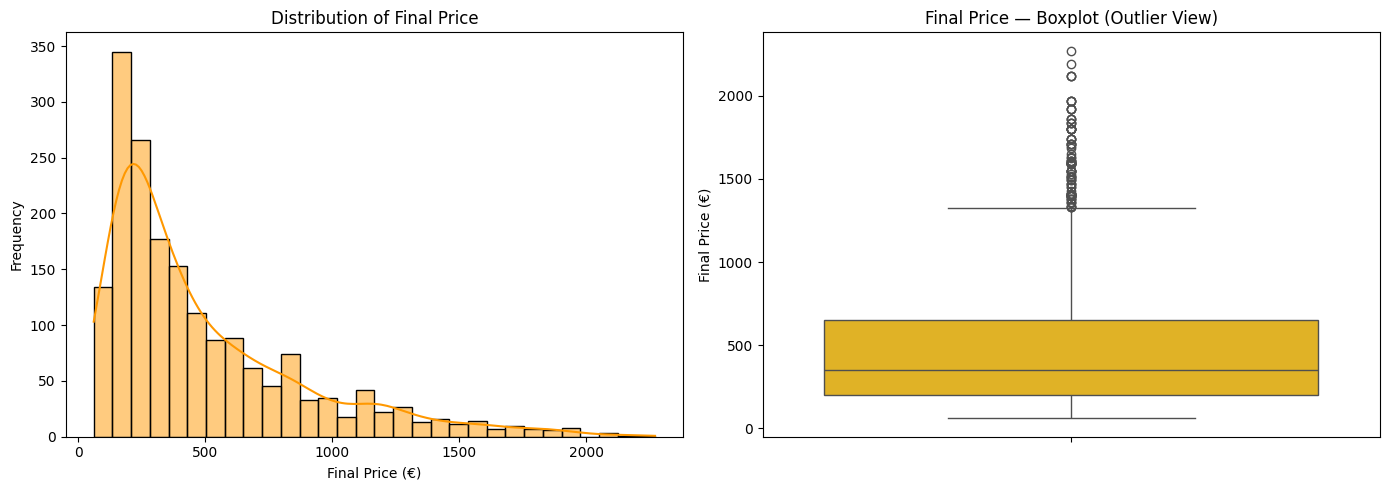

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_original["Final Price"], kde=True, color="#FF9800", ax=axes[0])
axes[0].set_title("Distribution of Final Price")
axes[0].set_xlabel("Final Price (€)")
axes[0].set_ylabel("Frequency")

sns.boxplot(y=df_original["Final Price"], color="#FFC107", ax=axes[1])
axes[1].set_title("Final Price — Boxplot (Outlier View)")
axes[1].set_ylabel("Final Price (€)")

plt.tight_layout()
plt.show()

The distribution is right-skewed — most smartphones are priced below €500, with a small number of premium devices above €1500. The boxplot on the right clearly highlights those high-price outliers.

### 11.2 RAM vs Final Price

/tmp/ipykernel_4968/2089290917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="RAM", y="Final Price", data=df_original, palette="YlOrRd")


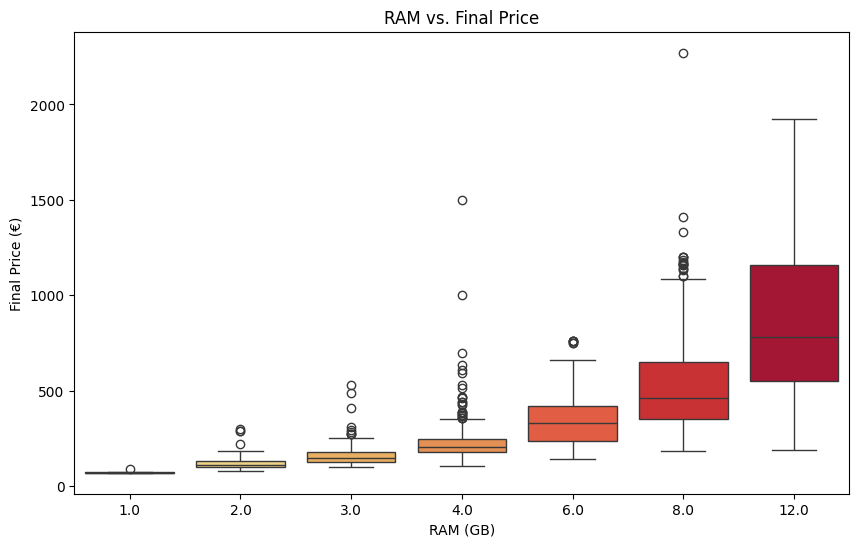

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="RAM", y="Final Price", data=df_original, palette="YlOrRd")
plt.title("RAM vs. Final Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Final Price (€)")
plt.show()

> **FIX:** Changed from scatter plot to **boxplot** for RAM vs Price. RAM takes a small set of discrete values (2–12 GB), so a scatter plot produces overplotted blobs with no clear shape. A boxplot correctly shows median, spread, and outliers at each RAM level.

### 11.3 Pairplot by Price Category

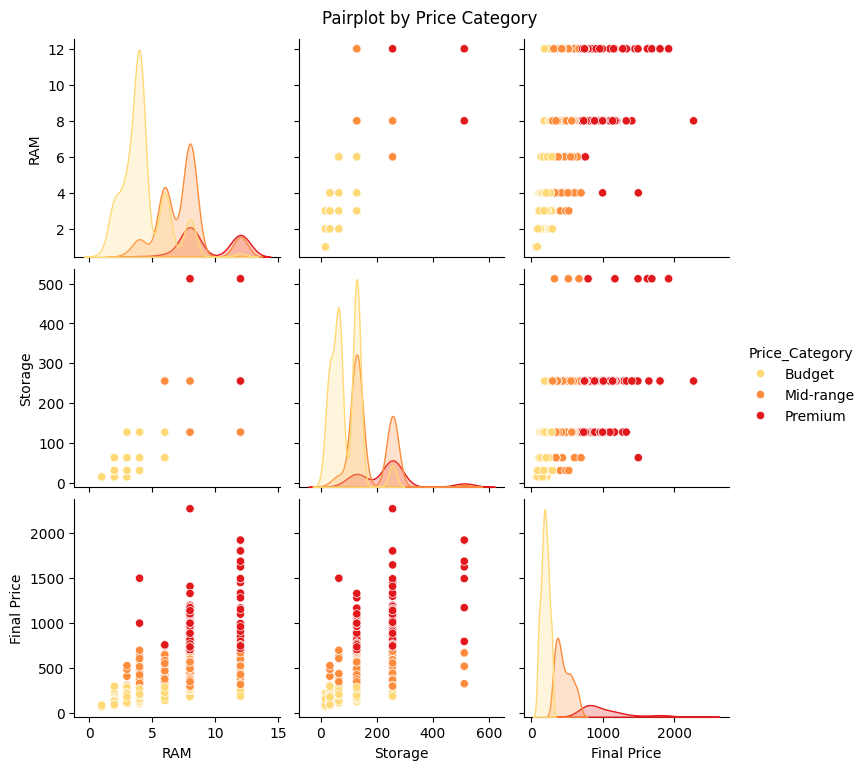

In [27]:
sns.pairplot(
    df_original[["RAM", "Storage", "Final Price", "Price_Category"]].dropna(),
    hue="Price_Category",
    palette="YlOrRd"
)
plt.suptitle("Pairplot by Price Category", y=1.02)
plt.show()

### 11.4 Average Final Price by Brand

/tmp/ipykernel_4968/1018264733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Brand", y="Final Price", data=avg_price, palette="YlOrRd")


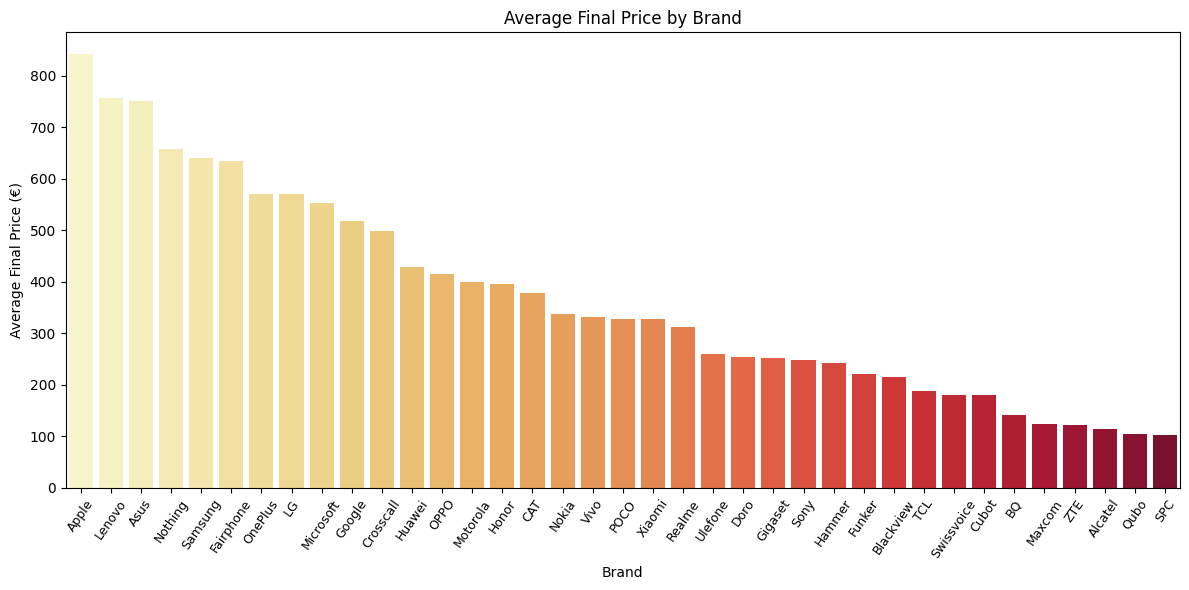

In [28]:
avg_price = df_original.groupby("Brand")["Final Price"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="Brand", y="Final Price", data=avg_price, palette="YlOrRd")
plt.title("Average Final Price by Brand")
plt.xticks(rotation=55, size=9)
plt.ylabel("Average Final Price (€)")
plt.tight_layout()
plt.show()

Apple and Samsung lead in average price, reflecting their premium positioning. Xiaomi, Realme, and TCL are more budget-oriented.

### 11.5 Storage vs Final Price

/tmp/ipykernel_4968/4269142335.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Storage", y="Final Price", data=df_original, palette="Oranges")


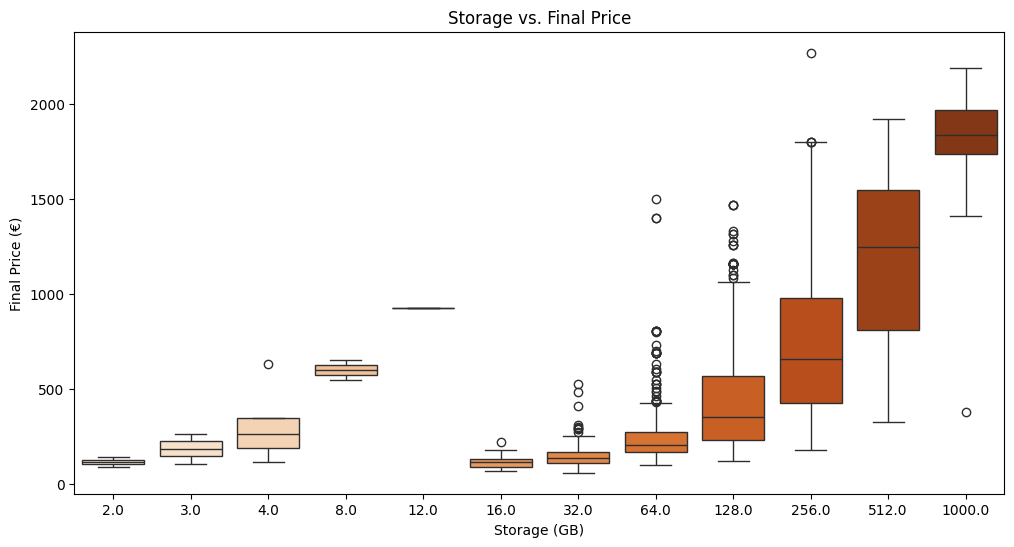

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Storage", y="Final Price", data=df_original, palette="Oranges")
plt.title("Storage vs. Final Price")
plt.xlabel("Storage (GB)")
plt.ylabel("Final Price (€)")
plt.show()

### 11.6 Top 10 Colors in Smartphones

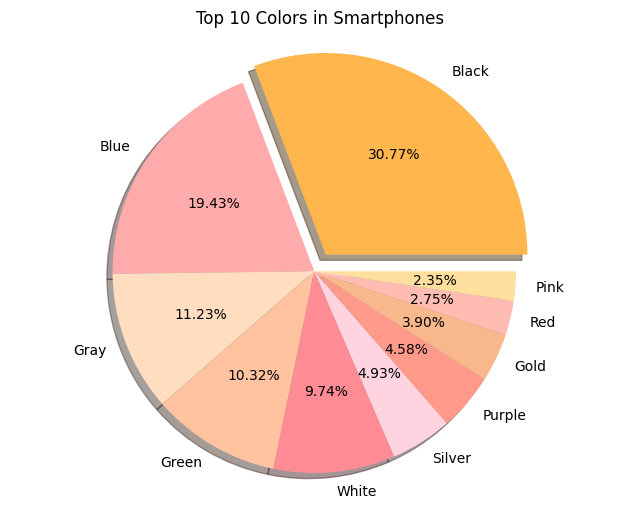

In [30]:
top10_color = df_original["Color"].value_counts().head(10)

plt.figure(figsize=(8, 6))
plt.pie(
    top10_color,
    labels=top10_color.index,
    autopct="%1.2f%%",
    explode=[0.1] + [0]*9,
    shadow=True,
    colors=["#FFB74D", "#FFABAB", "#FFDDC1", "#FFC3A0", "#FF8C94",
            "#FFD4E0", "#FF9A8B", "#F8B88B", "#FFBCB3", "#FFDF9D"]
)
plt.title("Top 10 Colors in Smartphones")
plt.axis("equal")
plt.show()

Black, Blue, and White dominate smartphone color options, reflecting broad consumer appeal. These neutral tones consistently outsell bolder colors.

### 11.7 RAM Distribution of Top 10 Brands

/tmp/ipykernel_4968/3292387643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Brand", y="RAM", data=df_top10, palette=colors)


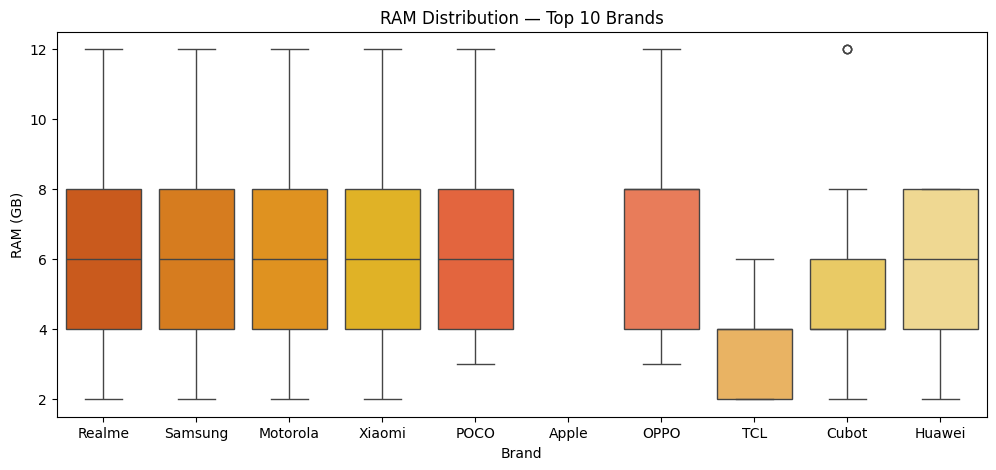

In [31]:
top_10_brands = df_original["Brand"].value_counts().head(10).index
df_top10 = df_original[df_original["Brand"].isin(top_10_brands)]

plt.figure(figsize=(12, 5))
sns.boxplot(x="Brand", y="RAM", data=df_top10, palette=colors)
plt.title("RAM Distribution — Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("RAM (GB)")
plt.show()

### 11.8 Correlation Heatmap

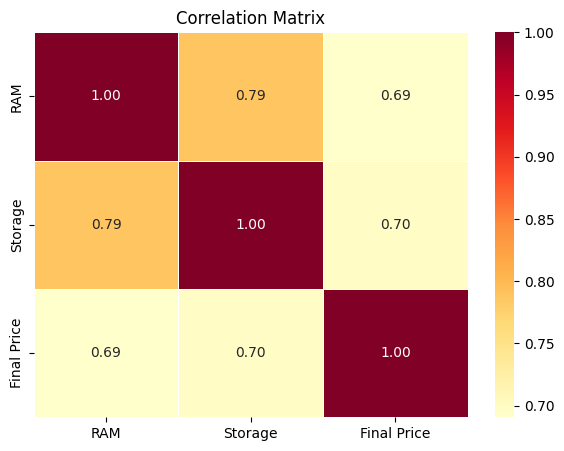

In [32]:
corr_cols = ["RAM", "Storage", "Final Price"]
plt.figure(figsize=(7, 5))
sns.heatmap(
    df_original[corr_cols].corr(),
    annot=True,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

Moderate positive correlations exist between RAM, Storage, and Final Price — higher specs generally mean higher prices. However, the correlations are not perfect, suggesting brand and other factors also play a role.

### 11.9 Price Category Distribution (NEW)

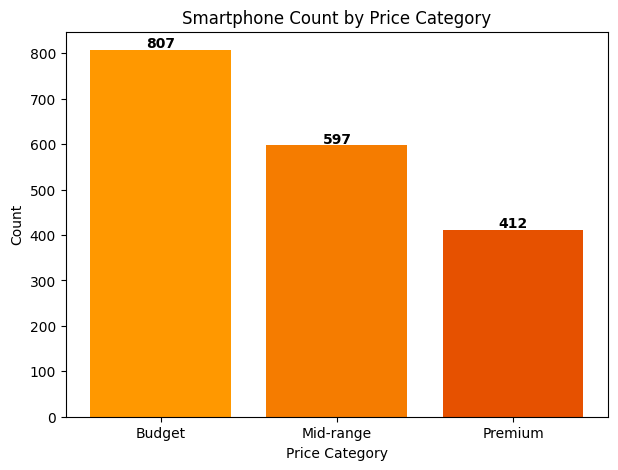

In [33]:
cat_counts = df_original["Price_Category"].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(cat_counts.index, cat_counts.values,
               color=["#FF9800", "#F57C00", "#E65100"])
plt.title("Smartphone Count by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Count")
for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontweight="bold")
plt.show()

### 11.10 Price per GB by Brand — Top 10 (NEW)

/tmp/ipykernel_4968/2947782387.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Brand", y="Price_per_GB", data=df_ppg_top,


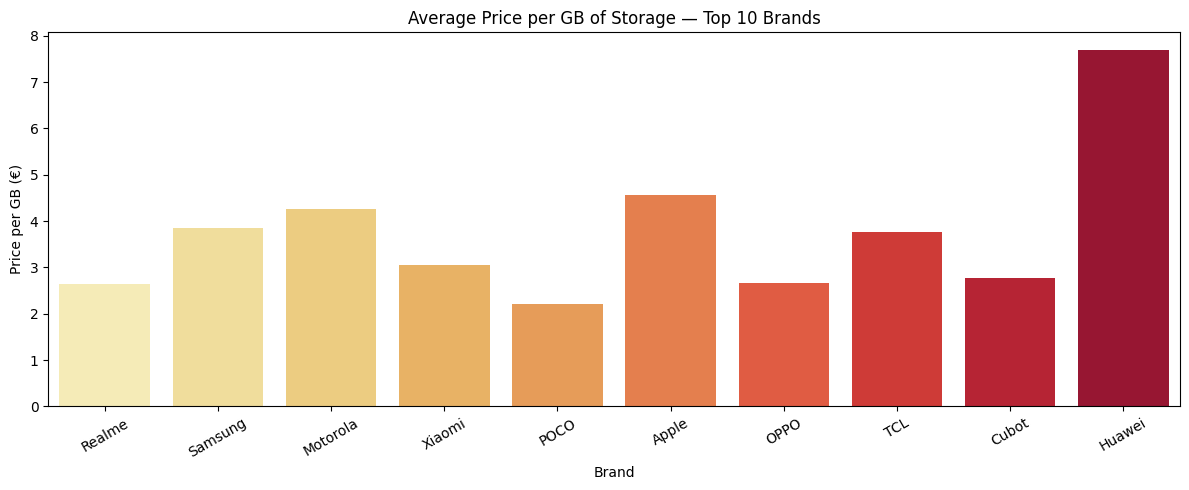

In [34]:
df_ppg = df_original.copy()
df_ppg["Price_per_GB"] = (df_ppg["Final Price"] / df_ppg["Storage"]).round(3)
df_ppg_top = df_ppg[df_ppg["Brand"].isin(top_10_brands)]

plt.figure(figsize=(12, 5))
sns.barplot(x="Brand", y="Price_per_GB", data=df_ppg_top,
            estimator="mean", palette="YlOrRd", errorbar=None)
plt.title("Average Price per GB of Storage — Top 10 Brands")
plt.ylabel("Price per GB (€)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

This chart reveals which brands offer the best value per GB of storage. Budget-oriented brands like Xiaomi and Realme tend to have lower price-per-GB ratios than Apple and Samsung.

<h1 style="color:#F57C00;">12. Final Dataset Summary</h1>

In [35]:
print("Final preprocessed dataset shape:", df_scaled.shape)
print("\nColumn list:")
for col in df_scaled.columns.tolist():
    print(" -", col)

Final preprocessed dataset shape: (1816, 58)

Column list:
 - RAM
 - Storage
 - Free
 - Final Price
 - Price_per_GB
 - Price_Category
 - Brand_Apple
 - Brand_Asus
 - Brand_BQ
 - Brand_Blackview
 - Brand_CAT
 - Brand_Crosscall
 - Brand_Cubot
 - Brand_Doro
 - Brand_Fairphone
 - Brand_Funker
 - Brand_Gigaset
 - Brand_Google
 - Brand_Hammer
 - Brand_Honor
 - Brand_Huawei
 - Brand_LG
 - Brand_Lenovo
 - Brand_Maxcom
 - Brand_Microsoft
 - Brand_Motorola
 - Brand_Nokia
 - Brand_Nothing
 - Brand_OPPO
 - Brand_OnePlus
 - Brand_POCO
 - Brand_Qubo
 - Brand_Realme
 - Brand_SPC
 - Brand_Samsung
 - Brand_Sony
 - Brand_Swissvoice
 - Brand_TCL
 - Brand_Ulefone
 - Brand_Vivo
 - Brand_Xiaomi
 - Brand_ZTE
 - Color_Blue
 - Color_Bronze
 - Color_Brown
 - Color_Crystal
 - Color_Gold
 - Color_Gray
 - Color_Green
 - Color_Orange
 - Color_Pink
 - Color_Purple
 - Color_Rainbow
 - Color_Red
 - Color_Silver
 - Color_Turquoise
 - Color_White
 - Color_Yellow


<h1 style="color:#F57C00;">Conclusion</h1>

This project provided valuable insights into the smartphone market through systematic data preprocessing and visualizations.

**Feature-Price Relationship**: Smartphones with higher RAM and storage tend to be priced higher, confirming these specs are key premium indicators.

**Brand Pricing**: Significant price variation across brands reflects differences in market positioning, demographics, and brand value.

**Contract Status**: Whether a phone is carrier-contract-free does not significantly influence its RAM, storage, or price.

**Consumer Preferences**: Black, Blue, and White dominate color choices, reflecting broad consumer preferences.

**Value for Money**: Price-per-GB analysis reveals that budget brands like Xiaomi and Realme deliver more storage per euro spent.

The cleaned and encoded dataset is now ready for machine learning tasks such as price prediction or market segmentation.

<p style="background-color:#FF9800;font-family:Georgia;font-size:200%;color:black;text-align:center;border-radius:20px 20px;"><b>THANK YOU!</b></p>